## 顺序链之SimpleSequentialChain的使用（不建议使用，官方已经不维护这个方法了）

单个输入/输出：对应着`SimpleSequentialChain`

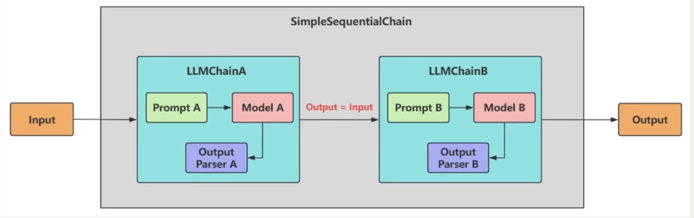

In [44]:
# 方式一：已经不维护了
from langchain_classic.chains.llm import LLMChain
from langchain_classic.chains.sequential import SimpleSequentialChain
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import os
import dotenv
dotenv.load_dotenv(dotenv_path='../chapter02-model IO/.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")


# 定义链
chain_one = LLMChain(llm=ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
), prompt=ChatPromptTemplate.from_template("写一句话关于{topic}"))
chain_two = LLMChain(llm=ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
), prompt=ChatPromptTemplate.from_template("将以下内容翻译成英文: {text}"))

# 使用 SimpleSequentialChain
overall_chain = SimpleSequentialChain(chains=[chain_one, chain_two])
result = overall_chain.run("猫")
print( result)

Cats, with their soft bodies and lively eyes, always manage to steal your heart without you noticing.


In [17]:
# 方式二：使用管道符,建议使用
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
import dotenv
dotenv.load_dotenv(dotenv_path='../chapter02-model IO/.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")
model = ChatOpenAI(model='tongyi-xiaomi-analysis-pro')

# 步骤 1：生成一个笑话
prompt1 = ChatPromptTemplate.from_template("讲一个关于 {topic} 的简短笑话。")
chain1 = prompt1 | model  | StrOutputParser()

# 步骤 2：将笑话翻译成法语
prompt2 = ChatPromptTemplate.from_template("将以下笑话翻译成法语：{joke}")
chain2 = prompt2 | model | StrOutputParser()

# 通过管道符串联 (这正是 SimpleSequentialChain 的现代替代品)
sequential_chain = chain1 | chain2

# 执行
result = sequential_chain.invoke({"topic": "猫"})
print(result)

Pourquoi les chats n'aiment-ils pas surfer sur Internet ?
Parce qu'ils ont peur d'être "clicqués" (cliqués) ! 

Note: 在法语中，“猫片”并没有直接对应的词，所以这里用了一个创造性的翻译“clicqués”，它是由“cliquer”（点击）这个词变化而来，用来模仿中文笑话中的双关语效果。在实际使用中，可能需要根据上下文和听众的理解程度来调整这个翻译。


## 顺序链之SequentialChain的使用

多个输入/输出：对应着`SequentialChain`:LLMChainA输入变量有Input1和Input2有多个，LLMChainB也可以有多个变量，有Input1或者Input2或者LLMChainA的输出作为输入

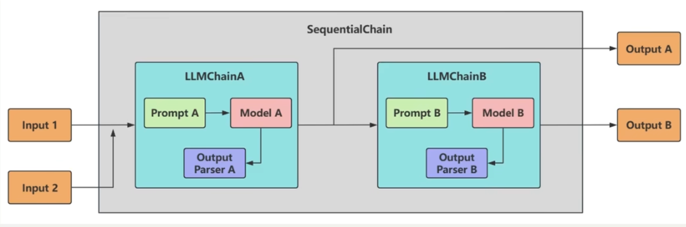

In [45]:

# 方式一：已经不维护了
from langchain_openai import ChatOpenAI
from langchain_classic.chains.sequential import SequentialChain
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.llm import LLMChain
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../chapter02-model IO/.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")

model =  ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',
    temperature=0.6
)
# chain1需要2个输入，会输出一个变量output_text
chain_one=LLMChain(
    llm=model,
    prompt=ChatPromptTemplate.from_template("写一个关于 {topic} 的笑话。并且翻译成{action}"),
    output_key="output_text"
)
# chain2需要1个输入（需要chain1的输出），会输出一个变量output_text2
chain_two=LLMChain(
    llm=model,
    prompt=ChatPromptTemplate.from_template("从{output_text}笑话获得什么启发"),
    output_key="output_text2"
)
overall_chain = SequentialChain(
    chains=[chain_one, chain_two],
    input_variables=["topic","action"],
    output_variables=["output_text","output_text2"]
)
result = overall_chain.invoke({"topic": "猫", "action": "韩语"})
print(result)

{'topic': '猫', 'action': '韩语', 'output_text': '中文笑话：\n为什么猫不喜欢上网？\n因为它们害怕被“猫”联网！\n\n韩语翻译：\n왜 고양이가 인터넷을 싫어할까요?\n그들은 "캣넷"에 연결되는 것을 두려워하기 때문입니다! (왜냐하면 "고양이"와 "인터넷"을 합쳐서 "캣넷"이라고 표현하기 때문입니다.)', 'output_text2': '这个中文笑话和韩语翻译都运用了语言的双关和拼接技巧，通过将“猫”和“互联网”结合，创造出“猫联网”和“캣넷”（Cat-net）这样的新词，制造出幽默效果。这启发我们：\n\n1. **语言的创造性**：通过巧妙地组合或变形现有词汇，可以创造出新的表达方式，带来新鲜感和幽默感。\n2. **文化共鸣**：笑话利用了“猫”这一普遍喜爱的动物形象与现代生活中的“上网”行为，形成反差，容易引起共鸣。\n3. **双关与谐音**：利用词语的多重含义或相似发音，制造出意料之外的效果，是许多语言中常见的幽默手法。\n4. **跨语言幽默**：尽管笑话在不同语言中需要调整表达方式，但其核心创意（如词汇拼接）可以跨文化传递，说明幽默的普遍性和可翻译性。\n\n这种类型的笑话提醒我们，语言不仅是沟通的工具，也是创造和享受幽默的媒介。'}


In [46]:
# 方式二：使用管道符
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
import os
import dotenv

dotenv.load_dotenv(dotenv_path='../chapter02-model IO/.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY2")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL2")

model =  ChatOpenAI(
    model='tongyi-xiaomi-analysis-pro',

)

# 步骤 1：生成笑话
chain1 = (
    ChatPromptTemplate.from_template("写一个关于 {topic} 的笑话。")
    | model
    | StrOutputParser()
)

# 步骤 2：生成评论，同时保留原始输入 (passthrough) 和笑话本身
# 使用 RunnableParallel 并行处理，将 chain1 的结果传递给 chain2
chain2 = (
    RunnableParallel(joke=chain1, topic=RunnablePassthrough())
    | ChatPromptTemplate.from_template("评价一下这个笑话: {joke}\n关于主题: {topic}")
    | model
    | StrOutputParser()
)
'''
    RunnableParallel：这是一个并行运行器，它允许同时执行多个子链（或可运行对象），并将它们的结果收集到一个字典中，键为指定的名称。
    topic=RunnablePassthrough()：这里的 topic 也是一个键名，对应的值是一个 RunnablePassthrough。RunnablePassthrough 是一个特殊的可运行对象，它不做任何处理，直接将输入传递下去。它通常用于在并行运行中保留输入数据。也就是说，当整个 RunnableParallel 被调用时，输入（例如一个包含 topic 的字典）会原样传递到 topic 键下。这样，输出字典中就会包含 joke（来自 chain1）和 topic（来自原始输入）。
'''
final_chain=(
    RunnableParallel(joke=chain2, topic=RunnablePassthrough())
    | ChatPromptTemplate.from_template("{joke}翻译成英文")
    | model
    | StrOutputParser()
)
# 执行
result = final_chain.invoke({"topic": "熊猫"})
print(result)



This joke employs a pun by linking the word for "bamboo" (竹) with the "zhǔ" in "main food" (主食), while also echoing "bamboo" with "the best" (最棒), creating a humorous effect. Centered around the theme of pandas, it accurately captures the fact that pandas primarily eat bamboo, making it both amusing and factually贴近. Overall, the joke is concise and clever, suitable for lightheartedly introducing the dietary habits of pandas.

For a more natural English translation, you might consider:
This joke plays on words, connecting "bamboo" with the character for "main" in "main food," and cleverly tying "bamboo" to "the best," for a playful punchline. Focused on pandas, it highlights the truth that bamboo is their staple diet, blending humor with fact. The joke is succinct and smart, perfect for a fun introduction to what pandas like to eat.
